/tmp/ipykernel_3707757/2274536217.py:17: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  buffer_ = np.fromstring(h.read(), np.uint8)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..640.0].


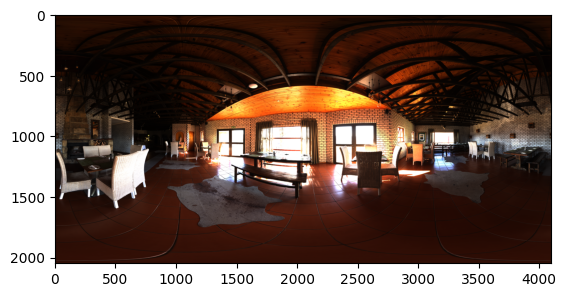

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_hdr(path):
    # TODO: will this support openexr? could not find valid openexr python binding
    # TODO: implement saving in hdr format
    """Reads an HDR map from disk.

    Args:
        path (str): Path to the .hdr file.

    Returns:
        numpy.ndarray: Loaded (float) HDR map with RGB channels in order.
    """
    with open(path, 'rb') as h:
        buffer_ = np.fromstring(h.read(), np.uint8)
    bgr = cv2.imdecode(buffer_, cv2.IMREAD_UNCHANGED)
    # bgr = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.float32)

hdr_path = '/data3/lihaochen/datasets/HDR/warm_restaurant_4k.hdr'

hdr = read_hdr(hdr_path)

plt.imshow(hdr)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0325493].


tensor(0.8000) tensor(0.2952)


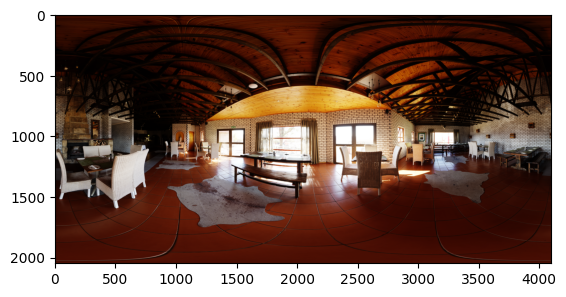

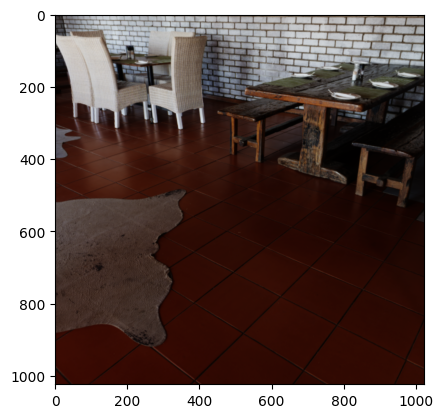

In [41]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import sys
import torch
from torch.nn import functional as F

def ACESToneMapping(color, adapted_lum):
    A = 2.51
    B = 0.03
    C = 2.43
    D = 0.59
    E = 0.14

    color *= adapted_lum
    return (color * (A * color + B)) / (color * (C * color + D) + E)

def render_camera_view_from_panorama(panorama, camera_directions):
    """
    panorama: 输入全景图 (Equirectangular HDR)
    K: 相机的内参矩阵 3x3
    R: 旋转矩阵 3x3
    T: 平移向量 3x1
    img_width: 渲染结果的宽度
    img_height: 渲染结果的高度
    """
    camera_directions = camera_directions.numpy()

    # 将世界坐标系中的方向向量转换为球面坐标（经度、纬度）
    theta = np.arctan2(-camera_directions[..., 1], camera_directions[..., 0])
    phi = np.arcsin(camera_directions[..., 2])

    # 将球面坐标映射回全景图的像素坐标
    u = (theta / (2 * np.pi) + 0.5) * panorama.shape[1]
    v = (-phi / np.pi + 0.5) * panorama.shape[0]

    # 采样全景图的颜色值（使用双线性插值）
    sampled_image = cv2.remap(panorama, u.astype(np.float32), v.astype(np.float32), cv2.INTER_CUBIC, borderMode=cv2.BORDER_WRAP)

    return sampled_image

def sample_envmap_image(image: torch.Tensor, ray_d: torch.Tensor):
    ray_d = ray_d.type(torch.float32)
    sh = ray_d.shape
    if image.ndim == 4:
        image = image[0]
    h, w = ray_d.size()[:2]
    ind = h // 2 * w + w // 2
    ray_d = ray_d.view(-1, 3)
    # envmap: H, W, C
    # viewdirs: N, 3

    # https://github.com/zju3dv/InvRender/blob/45e6cdc5e3c9f092b5d10e2904bbf3302152bb2f/code/model/sg_render.py
    image = image.permute(2, 0, 1).unsqueeze(0)

    theta = torch.arccos(ray_d[:, 2]).reshape(-1) - 1e-6
    phi = torch.atan2(ray_d[:, 1], ray_d[:, 0]).reshape(-1)  # 0 - pi

    # normalize to [-1, 1]
    print(-torch.atan2(ray_d[ind, 1], ray_d[ind, 0]) / torch.pi, torch.arccos(ray_d[ind, 2]) / torch.pi * 2 - 1)
    query_y = (theta / torch.pi) * 2 - 1
    query_x = - phi / torch.pi
    grid = torch.stack((query_x, query_y)).permute(1, 0).unsqueeze(0).unsqueeze(0)

    rgb = F.grid_sample(image, grid, align_corners=False, padding_mode='border')
    rgb = rgb.squeeze().permute(1, 0)
    return rgb.view(sh)

def normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    # channel last: normalization
    return x / (x.norm(dim=-1, keepdim=True) + eps)

def get_rays(H: int, W: int, K: torch.Tensor, R: torch.Tensor, T: torch.Tensor, subpixel=False):
    # calculate the camera origin
    ray_o = -(R.mT @ T).ravel()
    # calculate the world coodinates of pixels
    i, j = torch.meshgrid(torch.arange(H, dtype=R.dtype, device=R.device),
                          torch.arange(W, dtype=R.dtype, device=R.device),
                          indexing='ij')
    # 0->H, 0->W
    xy1 = torch.stack([j, i, torch.ones_like(i)], dim=2)
    if subpixel:
        rand = torch.rand(H, W, 2, device=R.device, dtype=R.dtype) - 0.5
        xy1[:, :, :2] += rand
    pixel_camera = xy1 @ torch.inverse(K).mT
    pixel_world = (pixel_camera - T.ravel()) @ R
    # calculate the ray direction
    ray_o = ray_o[None, None].expand(pixel_world.shape)
    ray_d = normalize(pixel_world - ray_o)
    return ray_o, ray_d

def get_(cams, index):
    return cams['K'][index], cams['R'][index], cams['T'][index]

# os.chdir(os.path.dirname(os.path.abspath(__file__)))
img = cv2.imread('/data3/lihaochen/datasets/HDR/warm_restaurant_4k.hdr', cv2.IMREAD_UNCHANGED)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = ACESToneMapping(img, 1.0)

# pes = GetPerspective(img, 100, 00, -90, 1024, 1024)
cams = {}
cams = np.load('/data3/lihaochen/datasets/synthetic_human_pp/josh/annots.npy', allow_pickle=True).ravel()[0]
K, R, T = get_(cams['cams'], 1)
# R = np.array([[0, -1, 0], [0, 0, -1], [1, 0, 0]], dtype=np.double) # to center
# R = np.array([[0, 1, 0], [0, 0, -1], [-1, 0, 0]], dtype=np.double) # to back
ray_o, ray_d = get_rays(1024, 1024, torch.from_numpy(K), torch.from_numpy(R), torch.from_numpy(T))
# pes = render_camera_view_from_panorama(img, ray_d)
pes = sample_envmap_image(torch.from_numpy(img), ray_d)


plt.imshow(img)
plt.show()
plt.imshow(pes)
plt.show()
